In [2]:
import numpy as np
import matplotlib.pyplot as plt
import numba
import pygam

plt.style.use("aslak")
import pandas as pd
from density_core import DensityCore
from grinsted_firn_model import *

S51 = DensityCore.load("_prepared_data/S5-1hxct_density_core.pkl")
S52 = DensityCore.load("_prepared_data/S5-2adj_density_core.pkl")
EG = DensityCore.load("_prepared_data/EGRIP_density_core.pkl")

cores = [S51, S52, EG]
import pandas as pd

flowline_S51 = pd.read_parquet("_prepared_data/S5-1hxct_backtrajectory.parquet")
flowline_S52 = pd.read_parquet("_prepared_data/S5-2adj_backtrajectory.parquet")
flowline_EG = pd.read_parquet("_prepared_data/EGRIP_backtrajectory.parquet")

flowlines = [flowline_S51, flowline_S52, flowline_EG]
for ii in range(len(flowlines)):
    # downsample and order for modelling
    flowline = flowlines[ii]
    # keepers = flowline.t % (5 + 0 * (flowline.t / 200).astype(int)) == 0
    # flowline = flowline.loc[keepers]
    flowline.t = -flowline.t * 1.0
    flowlines[ii] = flowline.sort_values(by="t")

cores = cores[::2]
flowlines = flowlines[::2]

In [2]:
# todo - consider calculating this in 1_prep.... because then you can assign extra uncertainty for bias
from pygam import LinearGAM, s

core_uncertainties = []
for coreidx in range(len(cores)):
    core = cores[coreidx]
    z = core.raw_z
    r = core.raw_rho
    dr = r - np.interp(z, core.z, core.rho)
    gam = LinearGAM(s(0)).fit(z, (dr**2))
    core_uncertainties.append(np.sqrt(gam.predict(z)))

In [3]:
# parameterisation of a and nu.

rho = np.linspace(300, 921)
if True:

    def simple_afun(rho, a_min=0.1, a600=18.05, slope600=-15.78652 / 921, a300=180, slope300=-0.04):
        # def new_afun(rho, a_min, a600, slope600, a300, slope300):
        # params:
        rhat = rho / rhoi
        duvacrow = (1 + (2 / 3) * (1 - rhat)) * (rhat ** (-1.5))
        return a_min * duvacrow + a600 * np.exp(slope600 * (rho - 600)) * 1 + a300 * np.exp(slope300 * (rho - 300))

    def simple_bfun(rho, rhoc=400, alpha=2, a_fun=a_fun):
        # def new_bfun(rho, rhoc, alpha, a_fun):
        a = a_fun(rho)
        nu = sigmoidal_poisson(rho, rhoc=rhoc, alpha=alpha)
        return poisson_to_b(nu, a)

    def abfun_from_m(m):
        a_min, a600, slope600, a300, slope300, rhoc, alpha = m
        a_fun = lambda rho: simple_afun(rho, a_min, a600, slope600, a300, slope300)
        b_fun = lambda rho: simple_bfun(rho, rhoc, alpha, a_fun)
        return a_fun, b_fun

    m0 = np.array([0.1, 18.05, -15.78652 / 921, 180, -0.04, 400, 2])
    m0 = np.array([0.1, 1, -0.015, 10000, -0.05, 700, 1.5])  # closer to steady state fit.
    # m0 = np.array([1, 2.5, -0.015, 50000, -0.1, 700, 1.5])  # closer to previous fit.
    # m0 = np.array([7.64450290e-01, 2.45370533e00, -1.60778514e-02, 5.83517792e04, -1.01567484e-01, 6.43510988e02, 1.21261036e00])
    mbounds = np.array(([0.001, 10], [0.01, 100], [m0[2] * 10, 0], [1, 100000], [-1, 0], [0, 1000], [0.1, 4])).T
    a0fun, b0fun = abfun_from_m(m0)
    modeltype = "simple"

In [4]:
steadystate = pd.read_parquet("_output/steadystate_fit.parquet")

In [ ]:
if True:
    from scipy.interpolate import make_lsq_spline
    from scipy.ndimage import gaussian_filter1d

    sigmoid = lambda x: 1 / (1 + np.exp(-x))
    inverse_sigmoid = lambda y: np.log(y / (1 - y))

    N_interior = 14
    k = 3
    rho = steadystate.rho.values.copy()
    rho[0] = 300
    rho[-1] = 921

    # define spline knot locations:
    t_internal = np.linspace(rho[0], rho[-1], N_interior)

    # Full knot vector with endpoint multiplicity
    t = np.concatenate((np.repeat(rho[0], k), t_internal, np.repeat(rho[-1], k)))

    tnu = sigmoidal_poisson(rho, 600, 1.5)
    loga = np.log(steadystate.a.values)
    # tnu = inverse_sigmoid(steadystate.poisson.values * 1.9+0.05) #start where there is a gradient

    loga_spl = make_lsq_spline(rho, loga, t, k)
    print(len(loga_spl.c))
    tnu_spl = make_lsq_spline(rho, tnu, t, k)

    # ensure monotonic initial guess
    loga_spl.c = gaussian_filter1d(loga_spl.c, 2)
    assert np.all(np.diff(loga_spl.c) < 0), "monotonic check failed"
    tnu_spl.c = gaussian_filter1d(tnu_spl.c, 2)  # avoid overshooting 0.5
    # for ii in range(1, len(loga_spl.c)):
    #    loga_spl.c[ii] = np.min(loga_spl.c[ii - 1 : ii + 1])

    def new_afun(rho, c):
        loga_spl.c = c
        return np.exp(loga_spl(rho))

    def new_nufun(rho, c):
        tnu_spl.c = c
        return tnu_spl(rho)

    def abfun_from_m(m):
        ca = np.pad(m[:N_interior], (1, 1), constant_values=(m[0], m[N_interior - 1]))  # horizontal slope at endpoints
        cnu = np.pad(m[N_interior:], (1, 1), constant_values=(m[N_interior], m[-1]))  # horizontal slope at endpoints
        ca[0] = ca[1] - (ca[2] - ca[1])  # constant slope at start
        a_fun = lambda rho: new_afun(rho, ca)
        nu_fun = lambda rho: new_nufun(rho, cnu)
        b_fun = lambda rho: poisson_to_b(nu=nu_fun(rho), a=a_fun(rho))
        return a_fun, b_fun

    m0 = np.concatenate([loga_spl.c[1:-1], tnu_spl.c[1:-1]])
    logabounds = np.tile(np.log([0.001, m0[0] * 1e4]), [N_interior, 1])
    nubounds = np.tile([0, 0.5], [N_interior, 1])
    mbounds = np.concatenate([logabounds, nubounds]).T
    a0fun, b0fun = abfun_from_m(m0)
    modeltype = "spline"

16


In [6]:
np.max(m0[:N_interior]), np.min(loga_spl.c), logabounds[0, :]
# np.max(tnu_spl.c), nubounds[0,:]

(np.float64(6.129938176304412),
 np.float64(-0.8956288166710975),
 array([-6.90775528, 11.02352504]))

In [7]:
def _expand_to_length(param, target_length):
    """Expand scalar or 1D array to target length."""
    param = np.atleast_1d(param)
    return np.broadcast_to(param, (target_length,)) if param.size == 1 else param


def nonsteadyfirnmodel(tyr=np.linspace(0, 1000), e1=0, e2=0, bdot=0.1, T_celsius=-31, rho_surf=330, A_fun=A_fun, a_fun=a_fun, b_fun=b_fun):
    A = A_fun(T_celsius + 273.15)

    n = len(tyr)
    e1 = _expand_to_length(e1, n)
    e2 = _expand_to_length(e2, n)
    bdot = _expand_to_length(bdot, n)
    rho_surf = _expand_to_length(rho_surf, n)

    # outputs
    dM = np.zeros_like(tyr)  # the layer mass per m2 --- e.g. mass should be "lost" if there is horiz flow divergence.
    rho = np.zeros_like(tyr)
    # todo age of layer!
    dt = (tyr[1] - tyr[1]) * sec_per_year
    for tix in range(len(tyr)):
        ix = len(tyr) - tix - 1  # this is the surface index
        # add a new layer of snow
        dM[ix] = bdot[tix] * dt / sec_per_year  #
        rho[ix] = rho_surf[tix]
        if tix == 0:
            continue
        dt = (tyr[tix] - tyr[tix - 1]) * sec_per_year

        # only work on the indices below the surface but above solid ice
        rhoterm = rhoi - rho[ix + 1 :]
        bottom_index = np.flatnonzero(np.append(rhoterm, 0) == 0)[0]
        rhoterm = rhoterm[:bottom_index]
        curslice = slice(ix + 1, ix + 1 + bottom_index)
        # curslice = slice(ix + 1, -1)

        # update layers below
        sigma_zz = -np.cumsum(dM[ix : ix + bottom_index]) * g  # the mass of the deepest layer does not compress anything.
        # sigma_zz = -np.cumsum(dM[ix:-2]) * g  # the mass of the deepest layer does not compress anything.
        a = a_fun(rho[curslice])
        b = b_fun(rho[curslice])
        # ezz = gagliardini_ezz_vec(sigma_zz, a, b, A, e1[tix], e2[tix])
        ezz = gagliardini_ezz_vec2(sigma_zz, a, b, A, e1[tix], e2[tix])  # faster?

        # what is Drho/Dt:

        DrhoDt = -rho[curslice] * (e1[tix] + e2[tix] + ezz)  # snapshot balance equation
        dM[ix + 1 :] = dM[ix + 1 :] * np.exp(-dt * (e1[tix] + e2[tix]))  # units sec per year...
        # rho[curslice] = rhoi - rhoterm * np.exp(-DrhoDt * dt / rhoterm)  # herron-langway style updating rule
        r0 = rho[curslice]
        rho[curslice] = -(r0 * rhoi) / (np.exp(-(-DrhoDt * rhoi * dt) / (r0 * (r0 - rhoi - 1))) * (r0 - rhoi) - r0)

    dH = dM / rho
    z = np.cumsum(dH) - dH / 2
    return z, rho, dM

0.7740800599996873

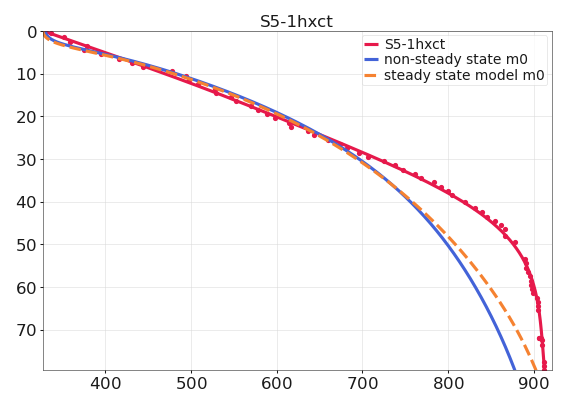

In [8]:
def model_coreindex(coreidx=0, m=m0):
    flowline = flowlines[coreidx]
    core = cores[coreidx]
    t = flowline.t.values * 1.0

    e1 = flowline.e1.values / sec_per_year
    e2 = flowline.e2.values / sec_per_year
    # e1 = e1 * 0 + core.e1 / sec_per_year
    # e2 = -e1 * 0 + core.e2 / sec_per_year
    bdot = core.bdot

    my_afun, my_bfun = abfun_from_m(m)
    z, rho, dM = nonsteadyfirnmodel(t, e1, e2, bdot, core.T, a_fun=my_afun, b_fun=my_bfun)
    return z, rho, dM


def core_deviance(coreidx=0, m=m0):
    core = cores[coreidx]
    z, rho, dM = model_coreindex(coreidx, m)
    return (np.interp(core.raw_z, z, rho) - core.raw_rho) / core_uncertainties[coreidx]


drho = loga_spl.t[4] - loga_spl.t[3]
prior_da1 = np.median(np.diff(loga_spl.c, 1) / drho)
prior_da2 = np.median(np.diff(loga_spl.c, 2) / drho**2)
prior_dnu2 = np.median(np.diff(tnu_spl.c, 2) / drho**2)


def model_penalty_term(m):
    ca = m[:N_interior]
    cnu = m[N_interior:]
    drho = loga_spl.t[4] - loga_spl.t[3]
    # monotonic test---
    da = np.diff(ca) / drho
    dnu = np.diff(cnu) / drho
    # return np.concatenate([da*(da>0) / 0.02, dnu*(dnu<0)/0.01]) # monotonicity penalty
    # smoothness test---
    da2 = np.diff(ca, 2) / drho**2
    dnu2 = np.diff(cnu, 2) / drho**2
    # return np.concatenate([da2, dnu2]) # smoothness penalty
    # convex a and smooth test
    # return da2 * (da2 < 0) / prior_da2
    return np.concatenate(
        [da2 * (da2 < 0) * 10 / prior_da2]
    )  # concave a penalty, but no penalty for nu. This is because nu is less well constrained and can be non-convex without causing issues.
    # return np.concatenate([da2 * (da2 > 0) / prior_da2, dnu2 / prior_dnu2])


def full_deviance(m):
    return np.concat([core_deviance(coreidx, m) for coreidx in range(len(cores))])


def penalized_deviance(m):
    return np.concatenate([full_deviance(m), model_penalty_term(m)])


coreidx = 0
z, rho, dM = model_coreindex(coreidx, m0)
import timeit

newafun, newbfun = abfun_from_m(m0)
cores[coreidx].plot(show_raw=True)
plt.plot(rho, z, label="non-steady state m0")
ssz, ssrho = density_profile(
    cores[coreidx].T + 273.15,
    1,
    cores[coreidx].bdot / sec_per_year,
    rho_s=cores[coreidx].rho[0],
    e1=cores[coreidx].e1 / sec_per_year,
    e2=cores[coreidx].e2 / sec_per_year,
    A_fun=A_fun,
    a_fun=newafun,
    b_fun=newbfun,
)
plt.plot(ssrho, ssz, "--", label="steady state model m0")
plt.title(cores[coreidx].site_name)
plt.legend()
timeit.timeit(lambda: model_coreindex(0, m0), number=10) / 10

In [9]:
from scipy.optimize import least_squares

# import pickle
import dill

# fscale_estimate = np.std(np.diff(cores[coreidx].raw_rho)/np.sqrt(2))

outputfilename = f"_output/5_least_squares_{modeltype}.dill"

if True:
    with open(outputfilename, "rb") as f:
        recall = dill.load(f)
        if len(recall["res"].x) == len(m0):
            res = recall["res"]
            m0 = recall["res"].x
            print("loaded previous fit as starting point")

if False:
    if modeltype == "simple":
        res = least_squares(full_deviance, m0, bounds=mbounds, xtol=1e-4)  # , loss="soft_l1", f_scale=10)  # , bounds=mbounds)  # , )
    else:
        res = least_squares(penalized_deviance, m0, bounds=mbounds, xtol=1e-3)  # , loss="soft_l1", f_scale=10)  # , bounds=mbounds)  # , )
    # ------------save it-----------
    with open(outputfilename, "wb") as f:
        to_save = {
            "abfun_from_m": abfun_from_m,
            "res": res,
            "m": res.x,
            "m0": m0,
            "full_deviance": full_deviance(res.x),
            "penalized_deviance": penalized_deviance(res.x),
            "reduced_chi2": np.mean(full_deviance(res.x) ** 2),
        }
        dill.dump(to_save, f)

loaded previous fit as starting point


In [10]:
m = res.x
afun, bfun = abfun_from_m(m)


# ------------------
# J = res.jac
# cov = np.linalg.inv(J.T @ J)
# m_mc = np.random.multivariate_normal(m, cov, size=100)

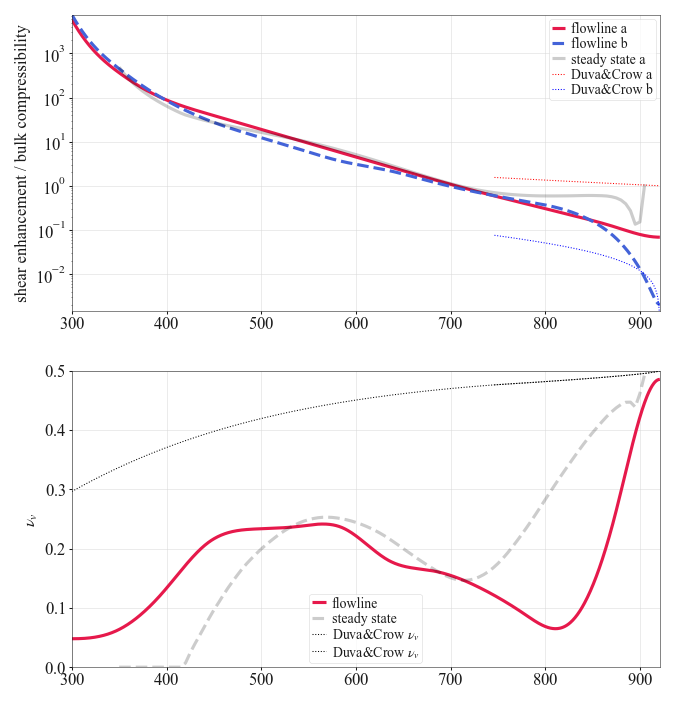

In [13]:
rho = np.linspace(300, 921, 1000)

import matplotlib as mpl

mpl.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman"],  # or "Palatino", "DejaVu Serif"
        "mathtext.fontset": "stix",  # matches Times-like math fonts
    }
)

salm77 = pd.read_csv("old data/salm77.csv")

# duvacrow
rdc = rho[rho > 0.81 * rhoi]
adc = a_fun(rdc)
bdc = b_fun(rdc)
nudc = poisson_from_ab(adc, bdc)


plt.figure(figsize=(4, 5))
plt.subplot(2, 1, 1)
plt.semilogy(rho, afun(rho), label="flowline a")
plt.semilogy(rho, bfun(rho), "--", label="flowline b")
plt.plot(steadystate.rho, steadystate.a, "k", alpha=0.2, label="steady state a")
# plt.plot(rho, a0fun(rho), "r--", alpha=0.2, label="m0")
# plt.plot(rho, b0fun(rho), "b--", alpha=0.2, label="m0")
plt.plot(rdc, adc, "r:", lw=0.5, label="Duva&Crow a")
plt.plot(rdc, bdc, "b:", lw=0.5, label="Duva&Crow b")
plt.legend()
plt.ylabel("shear enhancement / bulk compressibility")

plt.subplot(2, 1, 2)
plt.plot(rho, poisson_from_ab(afun(rho), bfun(rho)), label="flowline")
plt.plot(steadystate.rho, steadystate.poisson, "k--", alpha=0.2, label="steady state")
# plt.plot(rho, poisson_from_ab(a0fun(rho), b0fun(rho)), "r--", alpha=0.2, label="m0")
plt.ylabel("$\\nu_v$")
plt.plot(rdc, nudc, "k:", lw=0.5, label="Duva&Crow $\\nu_v$")
plt.plot(rho, poisson_from_ab(a_fun(rho), b_fun(rho)), "k:", lw=0.5, label="Duva&Crow $\\nu_v$")

if False:
    plt.plot(salm77.rho, 1 / salm77.inv_nu, "x", label="Salm77")
    rrr = rho[(rho > 170) & (rho < 740)]
    m_bader1951 = 1.48e3 / rrr * (1 - 0.8e-3 * rrr) * (1 + 3.87e-3 * rrr)  # from salm1977 fig11
    plt.plot(rrr, 1 / m_bader1951, "k--", lw=1, label="Bader51 from Salm1977")
    m_haeferli66 = (rrr / rhoi + 0.9) / (rrr / rhoi - 0.1)
    plt.plot(rrr, 1 / m_haeferli66, "b--", lw=1, label="Haeferli66")

plt.legend()

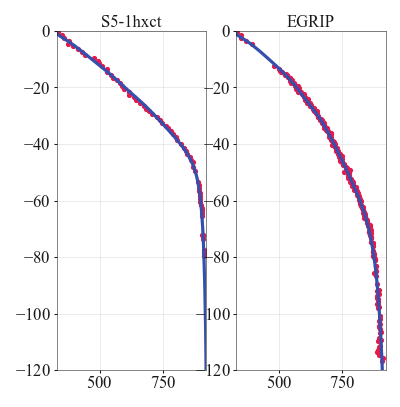

In [12]:
for coreidx in range(len(cores)):
    plt.subplot(1, 3, coreidx + 1)
    plt.plot(cores[coreidx].raw_rho, -cores[coreidx].raw_z, ".")
    z, rho, dM = model_coreindex(coreidx, m)
    plt.plot(rho, -z)
    z, rho, dM = model_coreindex(coreidx, m0)
    plt.plot(rho, -z, "k", alpha=0.2)
    plt.ylim([-120, 0])
    plt.title(cores[coreidx].site_name)

In [ ]:
coreidx = 1
z, rho, dM = model_coreindex(coreidx, m)
plt.plot(rho[z < 50], -z[z < 50])
plt.plot(cores[coreidx].raw_rho, -cores[coreidx].raw_z, ".")
plt.title(cores[coreidx].site_name)

plt.figure()
plt.plot(flowlines[coreidx].e2)

In [ ]:
afun(300)

In [ ]:
np.dif

In [ ]:
rho = steadystate.rho.values.copy()
rho[0] = 300
rho[-1] = 921
a = steadystate.a.values
nu = steadystate.poisson.values

loga = np.log(a)
from scipy.interpolate import make_lsq_spline

k = 3
N = 10
xmin, xmax = rho[0], rho[-1]
t_internal = np.linspace(xmin, xmax, N)

# Full knot vector with endpoint multiplicity
t = np.concatenate((np.repeat(t_internal[0], k + 1), t_internal, np.repeat(t_internal[-1], k + 1)))

loga_spl = make_lsq_spline(rho, np.random.randn(len(rho)), t, k)
print(len(loga_spl.c))

loga_spl(500)

In [ ]:
 np.mean(np.diff(loga_spl.c))

In [ ]:
dc = np.linspace(-2, 2)

plt.plot(dc, np.exp(-dc / -0.77) + 1)

In [ ]:
drho = loga_spl.t[4] - loga_spl.t[3]
dc = np.diff(tnu_spl.c) / drho
np.median(dc)

In [ ]:
np.median(np.diff(tnu_spl.c, 2) / drho**2)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("aslak")
x = np.linspace(0, 1)

y = x * x
np.diff(y, 2)

In [ ]:
plt.plot(model_penalty_term(m))

In [ ]:
da2 = np.diff(loga_spl.c, 2)
da2

In [ ]:
plt.semilogy(rho, afun(rho))

In [ ]:
import dill

In [ ]:
res

In [ ]:
import dill

with open("test.dill", "wb") as f:
    dill.dump([res, abfun_from_m], f)

In [ ]:
with open("test.dill", "rb") as f:
    q = dill.load(f)

In [ ]:
aa, bb = q[1](q[0].x)

In [ ]:
aa(700)

In [ ]:
res

In [ ]:
860 / 0.933

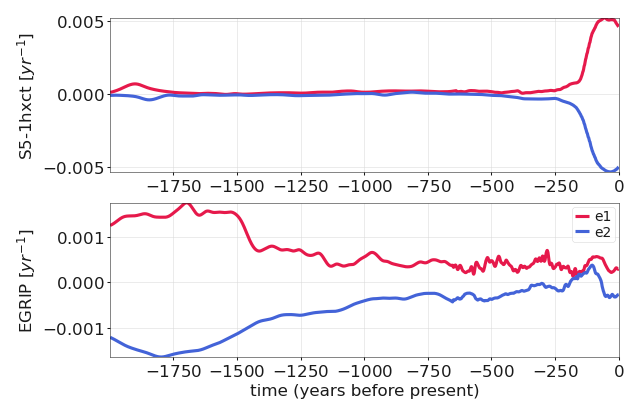

In [9]:
for i, flowline in enumerate(flowlines):
    plt.subplot(2, 1, i + 1)
    plt.plot(flowline.t, flowline.e1, label="e1")
    plt.plot(flowline.t, flowline.e2, label="e2")
    plt.ylabel(f"{cores[i].site_name} $[yr^{{-1}}]$")


plt.xlabel("time (years before present)")

plt.legend()